# Лабораторная работа 2. Обучение с учителем. Задача регрессии

**загрузка, линейная, поли, регуляризации, множественная** 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
from scipy.stats import zscore

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from math import sqrt
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
from sklearn.preprocessing import PolynomialFeatures

### Загрузка данных

In [3]:
data = pd.read_csv('../data/final_data_diamonds.csv')
data.drop(['Unnamed: 0'], axis=1, inplace=True)

### Первый шаг: выделение целевого признака и предикторов

In [4]:
y = data["price"]
X = data.drop(["price"], axis=1)
y

0         326
1         326
2         327
3         334
4         335
         ... 
53935    2757
53936    2757
53937    2757
53938    2757
53939    2757
Name: price, Length: 53940, dtype: int64

In [5]:
X

,carat,cut,color,clarity,depth,table,x,y,z
0,-1.199341,4,5,1,-0.176252,-1.096824,-1.587838,-1.573374,-1.593630
1,-1.241582,3,5,2,-1.381332,1.591635,-1.641325,-1.699003,-1.766179
2,-1.199341,1,5,4,-3.437054,3.383941,-1.498691,-1.492612,-1.766179
3,-1.072620,3,1,3,0.461732,0.247406,-1.364972,-1.349036,-1.306050
4,-1.030379,1,0,1,1.099714,0.247406,-1.240166,-1.241354,-1.133502
...,...,...,...,...,...,...,...,...,...
53935,-0.164447,4,6,2,-0.672462,-0.200671,0.016798,0.023908,-0.055076
53936,-0.164447,1,6,2,0.957939,-1.096824,-0.036690,0.014935,0.103093
53937,-0.206688,2,6,2,0.745278,1.143559,-0.063434,-0.047880,0.031198
53938,0.131237,3,2,1,-0.530687,0.247406,0.373383,0.346954,0.290021


### Второй шаг: разделение данных на обучающую и тестовую выборки

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [7]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((43152, 9), (43152,), (10788, 9), (10788,))

Итак, данные предобработаны, целевой признак выделен, имеются обучающая и тестовая выборка. Мы готовы приступить к обучению.

### Линейная регрессия (Linear Regression)

In [8]:
lr = LinearRegression().fit(X_train, y_train)
lr.predict(X_test)

array([ 386.18207422,  -10.41887488, 1925.34004895, ..., -621.71928613,
       9326.56046357, 4160.29939557], shape=(10788,))

In [9]:
y_pred = lr.predict(X_test)

In [10]:
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred)):.2f}')
print(f'R^2: {lr.score(X_test, y_test):.2f}')

MAE: 800.99
MSE: 1402050.05
RMSE: 1184.08
MAPE: 0.67
R^2: 0.91


In [11]:
len(lr.coef_)
lr.coef_

array([ 5124.49850495,   126.35428882,   327.38539185,   505.54832679,
         -94.97193028,   -49.97777137, -1510.22324887,   686.89550865,
        -161.10725357])

In [12]:
# L1
ridge = Ridge(alpha=0.5).fit(X_train, y_train)
y_pred = ridge.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred)):.2f}')
print(f'R^2: {lr.score(X_test, y_test):.2f}')
ridge.coef_

MAE: 801.04
MSE: 1402110.80
RMSE: 1184.11
MAPE: 0.67
R^2: 0.91


array([ 5122.9729639 ,   126.33243708,   327.36356369,   505.57392815,
         -94.88202089,   -50.01114644, -1504.20106221,   682.69102127,
        -161.42419208])

In [13]:
# L2
lasso = Lasso(alpha=0.5).fit(X_train, y_train)
y_pred = lasso.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred)):.2f}')
print(f'R^2: {lasso.score(X_test, y_test):.2f}')
lasso.coef_

MAE: 801.42
MSE: 1403445.91
RMSE: 1184.67
MAPE: 0.67
R^2: 0.91


array([ 5107.49396447,   125.35913686,   327.01700642,   506.11713792,
         -98.22266769,   -51.21275243, -1323.64929718,   489.84253303,
        -133.41427115])

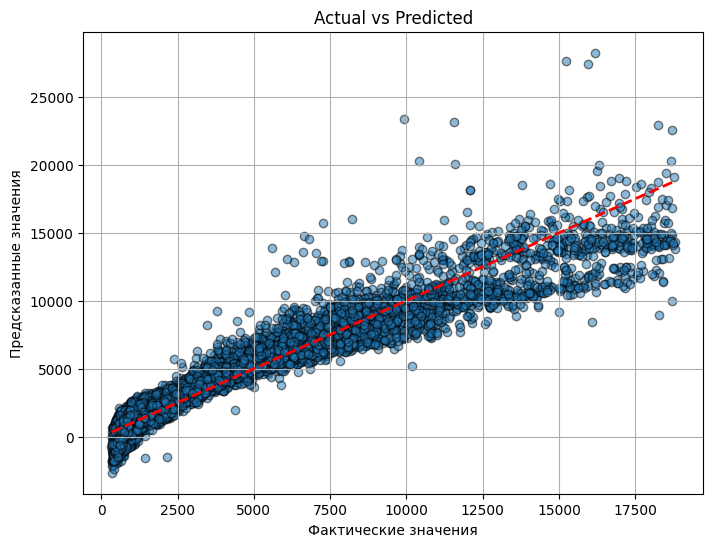

In [14]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title('Actual vs Predicted')
plt.grid(True)
plt.show()

In [15]:
parameters = {'alpha': np.arange(0, 1, 0.1)}    

In [16]:
ridge_optimal = GridSearchCV(Ridge(), parameters).fit(X_train, y_train)
ridge_optimal.best_params_

{'alpha': np.float64(0.9)}

In [ ]:
ridge_optimal = RandomizedSearchCV(Lasso(), parameters).fit(X_train, y_train)
ridge_optimal.best_params_

KeyError: slice(1, -1, 1)

In [ ]:
ridge_final = Ridge(alpha=0.9).fit(X_train, y_train)
y_pred_ridge = ridge_final.predict(X_test)

In [ ]:
# L1
ridge = Ridge(alpha=0.9).fit(X_train, y_train)
y_pred = ridge.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred)):.2f}')
print(f'R^2: {lr.score(X_test, y_test):.2f}')
ridge.coef_

MAE: 796.51
MSE: 1381312.09
RMSE: 1175.29
MAPE: 0.67
R^2: 0.91


array([ 5177.43809513,   127.8334501 ,   327.25496745,   501.55111117,
         -93.68178278,   -48.25371859, -1635.50087647,   768.77166904,
        -172.49809147])

In [ ]:
# L2
lasso = Lasso(alpha=0.9).fit(X_train, y_train)
y_pred = lasso.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred)):.2f}')
print(f'R^2: {lasso.score(X_test, y_test):.2f}')
lasso.coef_

MAE: 797.07
MSE: 1381954.86
RMSE: 1175.57
MAPE: 0.67
R^2: 0.91


array([ 5149.10554964,   125.82989531,   326.69767294,   502.6719427 ,
        -100.02284781,   -50.86337298, -1276.08312505,   385.00956257,
        -119.37370803])

In [ ]:
p = PolynomialFeatures(4)
X_p=pf.fit_transform(X)
X_p

array([[ 1.00000000e+00, -1.19934143e+00,  4.00000000e+00, ...,
         2.47550480e+00,  2.50737600e+00,  2.53965753e+00],
       [ 1.00000000e+00, -1.24158203e+00,  3.00000000e+00, ...,
         2.88660983e+00,  3.00074203e+00,  3.11938685e+00],
       [ 1.00000000e+00, -1.19934143e+00,  1.00000000e+00, ...,
         2.22789058e+00,  2.63621937e+00,  3.11938685e+00],
       ...,
       [ 1.00000000e+00, -2.06687922e-01,  2.00000000e+00, ...,
         2.29249248e-03, -1.49376981e-03,  9.73328494e-04],
       [ 1.00000000e+00,  1.31236743e-01,  3.00000000e+00, ...,
         1.20376925e-01,  1.00623740e-01,  8.41119426e-02],
       [ 1.00000000e+00, -1.01086456e-01,  4.00000000e+00, ...,
         1.50347914e-02,  1.79302707e-02,  2.13833767e-02]],
      shape=(53940, 55))

In [ ]:
lr2 = LinearRegression().fit(X_p, y)
lr2.coef_

array([ 2.22312413e-13,  2.23051081e+03, -2.01114007e+01,  9.65129339e+01,
        1.53678002e+02, -1.62863121e+02, -4.04496404e+00, -5.83002895e+02,
       -9.94456418e+02,  3.66290157e+02, -6.59255459e+02,  3.48101136e+02,
        2.09154773e+02,  6.43984215e+02,  9.30448753e+00,  9.93612195e+01,
       -1.85381838e+03,  1.73107574e+03,  1.37600562e+03,  4.21541109e+00,
        1.90729789e+01,  1.74828467e+00, -3.37284814e+01, -1.09939120e+01,
       -6.86829314e+02,  1.57448288e+02,  2.85499536e+02, -2.71399845e+01,
        1.20523171e+02,  2.81261792e+01,  4.56921073e+00, -5.88072338e+01,
        3.38638332e+02, -1.24000540e+02, -2.97934927e+00, -2.88007258e+00,
       -1.56910996e+01,  3.77841464e+02, -4.01672909e+02, -5.74765611e+01,
       -2.74109784e+01, -1.81845757e+01,  8.00978278e+01,  1.15765578e+02,
       -7.32787827e+01, -1.51809089e+01,  4.20890674e+02, -6.66966063e+02,
        1.38861227e+02, -1.74155018e+03,  2.67768070e+03,  1.04438975e+03,
        1.34077916e+03, -

In [ ]:
mlrm = LinearRegression().fit(X_train,y_train)
mlrm

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
pol = np.polyfit(data['carat'], data['price'], 5)
func = np.poly1d(pol)
print(func)

       5         4         3        2
12.85 x - 86.37 x - 153.8 x + 1019 x + 3634 x + 3291
